# L31 · 🎨 概率分布（Probability Distribution）可视化（Visualization） — PDF、CDF 与交叉熵（Cross Entropy，CE）损失曲面动态演示

配合 `s1–s4`，用六张图串联频率（Relative Frequency）收敛、分布形状、标准化、softmax 和交叉熵损失。Aurora 分类头（Classification Head）的 `softmax_cross_entropy` 直接依赖最后两张图的几何直觉。

**目标**：用 `matplotlib` 画出六张图——大数定律收敛曲线、均匀/正态 PDF 对比、高斯钟形 + 标准差区间、z-score 前后对比、softmax 柱状、交叉熵损失曲面——以及 Shannon 熵和 CDF 的手写可视化。

**为什么对 Aurora 重要**：分类头 `softmax_cross_entropy` 的数学直觉来自后两张图；Shannon 熵曲线解释了为什么最小化交叉熵等价于最小化 KL 散度；CDF 图对应特征归一化（normalization）的概率解释。

## 本课剧情：让随机留下形状

单次随机事件是噪声，大量重复后频率收敛到概率，样本（Sample）积累成可辨认的分布形状。这节课把这条链的每一步画出来：大数定律（Law of Large Numbers，LLN）的收敛曲线、正态分布（Normal Distribution）的标准差（Standard Deviation，SD）区间、z-score 标准化前后的对比，以及 softmax 把原始分数压成概率再由交叉熵量化为损失的过程。

In [1]:
from sviz import (style, law_of_large_numbers, dist_compare,
                  gaussian, zscore_demo, softmax_bars, cross_entropy_curve)
style(); print('sviz 就绪')

sviz 就绪


## 实验入口：概率量如何从样本里出现

观察两个控制变量：`n`（样本数）决定频率估计的稳定性，`sigma`（标准差）决定分布的宽窄。调大 `n`，频率曲线收敛更快；调大 `sigma`，钟形曲线铺宽、峰值下降。

## 动手观察：随机代码要多试几次

固定种子运行一次，记录 `n=100` 时的频率估计；再把 `n` 改成 `10000`，比较两次结果与真实概率 1/6 的偏差大小。

In [ ]:
import numpy as np

rng = np.random.default_rng(0)
for n in [10, 100, 10_000]:
    rolls = rng.integers(1, 7, size=n)
    estimate = np.mean(rolls == 6)
    print(f'n={n:5d}  频率估计={estimate:.4f}  (理论值 1/6≈0.1667)')


## 代码实验：多次重复同一个随机实验

这个实验展示样本量对频率波动的压制效果：`n` 每增大 10 倍，多次运行之间的估计方差（Variance）大约缩小 10 倍。

In [ ]:
import numpy as np

# 大数定律：重复5次实验，观察频率估计的波动随n收窄
for n in [20, 200, 2000]:
    estimates = []
    for seed in range(5):
        rng = np.random.default_rng(seed)
        rolls = rng.integers(1, 7, size=n)
        estimates.append(np.mean(rolls == 6))
    spread = max(estimates) - min(estimates)
    print(f'n={n:4d}  5次估计={np.round(estimates, 3)}  极差={spread:.4f}')


## 1. 大数定律：频率收敛到概率（对应 s1）

六张图从左到右构成一条认知链：频率收敛（图 1）说明概率可以从重复实验中估计；分布形状（图 2–3）刻画数据的统计结构；z-score 标准化（图 4）把不同尺度的特征统一量纲；softmax（图 5）把原始分数映射为合法概率；交叉熵（图 6）把预测概率与真实标签的差距量化为可微损失。这条链就是 ML 模型从原始数据到训练信号的数学骨架——每张图对应训练流水线的一个节点，跳过任何一步都会导致后续计算失去意义。

## 1a. 手写 LLN 收敛曲线（`np.cumsum`）

大数定律收敛曲线的核心公式只需一行：`running = np.cumsum(flips) / np.arange(1, n+1)`。
`np.cumsum` 把每次抛掷的结果（0/1）前缀求和，除以当前次数即得运行平均值（Running Mean）。
sviz 内部用的正是同一个公式——下面先显式写出，再用 sviz 画完整图。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 2000
flips = rng.integers(0, 2, size=n)  # 公平硬币：0=反，1=正

# 一行写出 LLN 运行平均
running = np.cumsum(flips) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(running, color='steelblue', lw=0.8, label='运行平均（频率）')
ax.axhline(0.5, color='tomato', lw=1.5, ls='--', label='理论概率 p=0.5')
ax.set_xlabel('投掷次数 n'); ax.set_ylabel('频率'); ax.legend()
ax.set_title('大数定律：np.cumsum 直接实现')
plt.tight_layout(); plt.show()

# 验证：到 n=2000 时偏差应 < 5%
assert abs(running[-1] - 0.5) < 0.05, f'频率偏差过大: {running[-1]:.4f}'

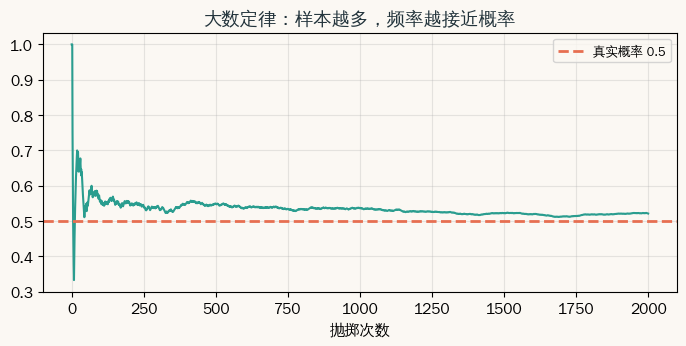

In [2]:
law_of_large_numbers();

## 2. 均匀分布（Uniform Distribution） vs 正态分布（对应 s3）

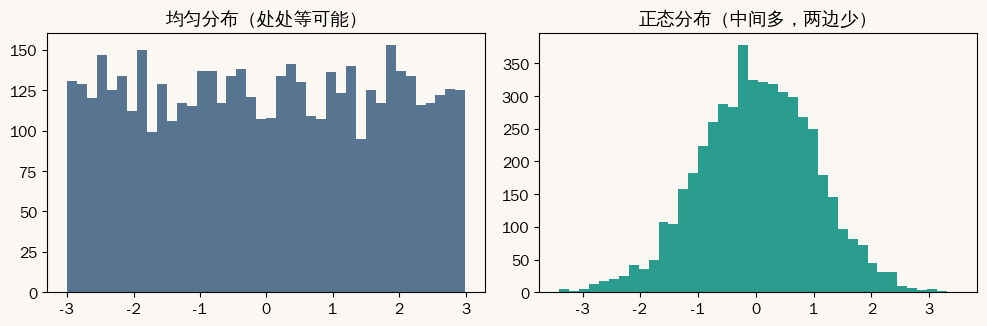

In [3]:
dist_compare();

## 3. 高斯钟形 + 标准差区间（对应 s3）

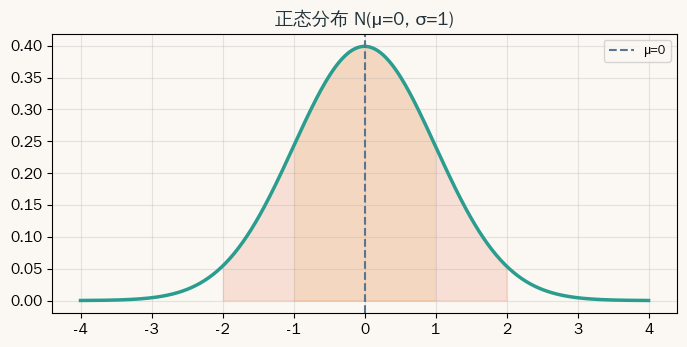

In [4]:
gaussian(0, 1);

## 4. z-score 标准化前后（对应 s2）

**🔗 Aurora**：特征喂入模型前必须标准化。Aurora 训练循环里的 `normalize_features` 对每个维度减均值（Mean）、除标准差；若跳过这步，不同频带的量级差距会让梯度（Gradient）在高能维度过大、在低能维度接近零，导致学习率无法在各层之间对齐，训练不稳定。实现位于 `src/aurora/audio/transforms.py`（`aurora.audio.normalize_features`）。

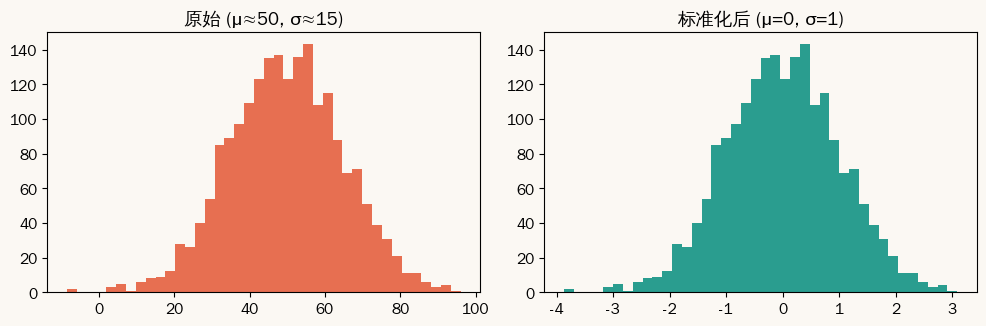

In [5]:
zscore_demo();

## 5. softmax：分数 → 概率（对应 s4）

**🔗 Aurora**：分类头的 `softmax_cross_entropy` 把最后一层的 logit 向量先过 softmax 转为合法概率分布（各维非负、和为 1），再对真实类别取负对数得到损失。两步合并用 log-sum-exp 技巧计算，避免 `np.exp(logit)` 在大数值下溢出。实现位于 `src/aurora/llm/sample.py`（`aurora.llm.softmax_cross_entropy`）。

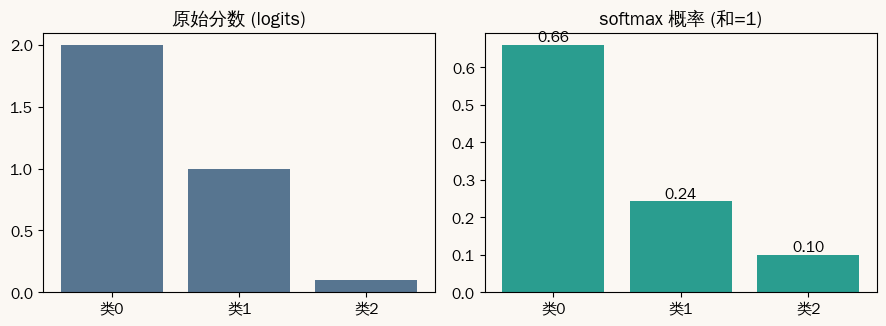

In [6]:
softmax_bars((2.0, 1.0, 0.1));

## 6. 交叉熵：越自信且正确，损失越小（对应 s4）

/home/user/AURORA/notebooks/prep_probability/sviz.py:109: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  fig.tight_layout(); return fig
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:100: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


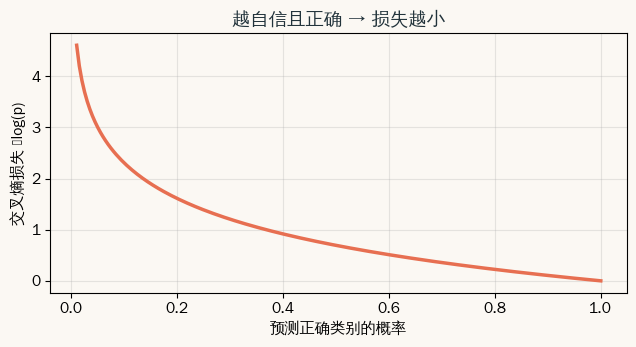

In [7]:
cross_entropy_curve();

## 7. 信息熵（Shannon Entropy）可视化 — 不确定性的形状

Shannon 熵 H(p) = −Σ pᵢ log₂ pᵢ 衡量一个概率分布"有多不确定"。  
两张图分别展示：
- **左图**：二元分布的 H(p) 随 p 变化的曲线——p=0.5 时最大（1 bit），p→0 或 p→1 时趋于 0
- **右图**：自熵 H(p) 与交叉熵 H(p,q) 的对比——H(p,q) = H(p) + KL(p‖q) ≥ H(p)，最小化交叉熵等价于最小化 KL 散度

## 练习：手写 `shannon_entropy(p)`

根据公式 **H(p) = −Σ pᵢ log₂ pᵢ**，实现下面的函数。

提示：
- 用 `np.where` 或布尔掩码跳过 pᵢ = 0 的项（0 log 0 定义为 0）。
- 返回值的单位是 **bit**（以 log₂ 为底）。
- 完成后下方断言应全部通过。

In [ ]:
import numpy as np

def shannon_entropy(p: np.ndarray) -> float:
    """计算离散概率分布 p 的 Shannon 熵（单位：bit）。

    参数
    ----
    p : array-like，各分量非负且和为 1

    返回
    ----
    float  熵值 ≥ 0，均匀分布时最大，确定性分布时为 0
    """
    # ── 在这里填写你的实现 ──────────────────────────────────
    raise NotImplementedError('请实现 shannon_entropy')
    # ────────────────────────────────────────────────────────


# ── 验证区 ──────────────────────────────────────────────────────────────
try:
    # 确定性分布：熵应为 0
    h0 = shannon_entropy(np.array([1.0, 0.0, 0.0]))
    assert abs(h0) < 1e-9, f'确定性分布熵应为 0，得到 {h0:.6f}'

    # 均匀二元分布：熵应为 1 bit
    h1 = shannon_entropy(np.array([0.5, 0.5]))
    assert abs(h1 - 1.0) < 1e-9, f'均匀二元分布熵应为 1.0 bit，得到 {h1:.6f}'

    # 均匀四元分布：熵应为 2 bit
    h2 = shannon_entropy(np.array([0.25, 0.25, 0.25, 0.25]))
    assert abs(h2 - 2.0) < 1e-9, f'均匀四元分布熵应为 2.0 bit，得到 {h2:.6f}'

    print('✓ 全部断言通过！你的 shannon_entropy 实现正确。')
except NotImplementedError:
    print('⚠ 尚未实现——请填写函数体后重新运行。')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：二元分布 H(p) 曲线 ─────────────────────────────────────────────
p = np.linspace(1e-9, 1 - 1e-9, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

ax1.plot(p, H, color='#2A9D8F', lw=2.5)
ax1.axvline(0.5, color='#E76F51', lw=1.2, ls='--', alpha=0.8)
ax1.scatter([0.5], [1.0], s=60, color='#E76F51', zorder=5)
ax1.annotate('H = 1 bit\n(均匀，不确定性最大)', (0.5, 1.0),
             xytext=(0.58, 0.82), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='#E76F51'))
ax1.set_xlabel('概率 p')
ax1.set_ylabel('熵 H(p)  [bits]')
ax1.set_title('二元分布 Shannon 熵\nH(p) = −p log₂p − (1−p) log₂(1−p)')
ax1.set_ylim(-0.05, 1.2)

# ── 右图：自熵 vs 交叉熵柱状对比 ─────────────────────────────────────────
def h_bits(p):
    p = np.asarray(p, float)
    return float(-np.sum(p[p > 0] * np.log2(p[p > 0])))

def hpq_bits(p, q):
    p = np.asarray(p, float)
    q = np.clip(np.asarray(q, float), 1e-15, None)
    return float(-np.sum(p * np.log2(q)))

p_true = np.array([0.7, 0.2, 0.1])
q_good = np.array([0.65, 0.25, 0.10])
q_bad  = np.array([0.10, 0.10, 0.80])

labels = ['H(p)\n自熵（下界）', 'H(p, q_好)\nKL 小', 'H(p, q_差)\nKL 大']
vals   = [h_bits(p_true), hpq_bits(p_true, q_good), hpq_bits(p_true, q_bad)]
colors = ['#2A9D8F', '#8AB17D', '#E76F51']

bars = ax2.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.04,
             f'{v:.3f}', ha='center', fontsize=10)
ax2.axhline(vals[0], color='#2A9D8F', ls='--', lw=1.2, alpha=0.6, label='H(p) 下界')
ax2.set_ylabel('信息量 [bits]')
ax2.set_title('H(p, q) = H(p) + KL(p‖q) ≥ H(p)\n最小化交叉熵 ≡ 最小化 KL 散度')
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
plt.show()

print(f'H(p)={vals[0]:.4f}  H(p,q_好)={vals[1]:.4f}  H(p,q_差)={vals[2]:.4f}')
assert vals[1] >= vals[0] - 1e-9 and vals[2] >= vals[0] - 1e-9
print('✅ H(p,q) ≥ H(p) 验证通过')

## 8. 累积分布函数（CDF）可视化 — Φ(x) = P(X ≤ x)

CDF 是 PDF 从 −∞ 到 x 的积分，完整描述"随机变量不超过某值的概率"。  
这里用数值积分（梯形法）计算标准正态 CDF Φ(x)——与 L29 的 `normal_cdf` 相同的原理，加上可视化。

> **68–95–99.7 经验法则**：Φ(1)−Φ(−1) ≈ 68%，Φ(2)−Φ(−2) ≈ 95%，Φ(3)−Φ(−3) ≈ 99.7%

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def normal_cdf(x_eval, mu=0.0, sigma=1.0, n=4000):
    xs  = np.linspace(mu - 6 * sigma, x_eval, n)
    return float(np.trapezoid(gaussian_pdf(xs, mu, sigma), xs))

x   = np.linspace(-4, 4, 600)
pdf = gaussian_pdf(x)
cdf = np.array([normal_cdf(xi) for xi in x])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：PDF + 面积着色 ──────────────────────────────────────────────────
fill_spec = [(1, '#2A9D8F', 0.55, '±1σ ≈ 68%'),
             (2, '#8AB17D', 0.35, '±2σ ≈ 95%'),
             (3, '#E9C46A', 0.20, '±3σ ≈ 99.7%')]
for sig, color, alpha, label in reversed(fill_spec):
    mask = (x >= -sig) & (x <= sig)
    ax1.fill_between(x[mask], pdf[mask], alpha=alpha, color=color, label=label)
ax1.plot(x, pdf, color='#22333B', lw=2)
ax1.set_xlabel('x'); ax1.set_ylabel('PDF f(x)')
ax1.set_title('标准正态 PDF\n68–95–99.7 经验法则')
ax1.legend(fontsize=9, loc='upper right')

# ── 右图：CDF Φ(x) ─────────────────────────────────────────────────────
ax2.plot(x, cdf, color='#2A9D8F', lw=2.5, label='Φ(x)')
ax2.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.6)
sigma_marks = [(1, '#2A9D8F'), (2, '#8AB17D'), (3, '#E9C46A')]
for sig, color in sigma_marks:
    y = normal_cdf(sig)
    ax2.scatter([sig], [y], s=45, color=color, zorder=5)
    ax2.annotate(f'Φ({sig})={y:.4f}', (sig, y),
                 xytext=(sig + 0.1, y - 0.05), fontsize=8.5, color=color)
ax2.set_xlabel('x'); ax2.set_ylabel('CDF Φ(x) = P(X ≤ x)')
ax2.set_title('标准正态 CDF（数值积分）\nΦ(x) = ∫_{−∞}^{x} f(t) dt')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

p68  = normal_cdf(1)  - normal_cdf(-1)
p95  = normal_cdf(2)  - normal_cdf(-2)
p997 = normal_cdf(3)  - normal_cdf(-3)
print(f'±1σ: {p68:.4f}  ±2σ: {p95:.4f}  ±3σ: {p997:.4f}')
assert abs(p68  - 0.6827) < 0.002
assert abs(p95  - 0.9545) < 0.002
assert abs(p997 - 0.9973) < 0.002
print('✅ CDF 数值积分验证通过：68–95–99.7 经验法则')

In [ ]:
import numpy as np

def softmax(z):
    e = np.exp(np.asarray(z, float) - np.max(z))
    return e / e.sum()

def cross_entropy(probs, idx):
    return float(-np.log(probs[int(idx)] + 1e-12))

# 不同置信度下交叉熵损失的数值变化
for scale in [0.5, 1.0, 2.0, 5.0]:
    z = np.array([2.0, 1.0, 0.0]) * scale
    p = softmax(z)
    loss = cross_entropy(p, 0)
    print(f'scale={scale:.1f}  P(目标类)={p[0]:.4f}  loss={loss:.4f}')


## 参数实验：logit 差距与模型置信度

在 softmax 图里，把三个 logit 从 `[2.0, 1.0, 0.0]` 改成 `[10.0, 5.0, 0.0]`，观察概率分布从接近均匀（各约 0.33）变为极度集中（第一个接近 1.0）。这演示了「温度（Temperature）」参数的作用：softmax 输入除以温度 T 等价于等比缩放差距——T < 1（拉大差距）时模型输出更自信，T > 1 时输出更平滑，常用于知识蒸馏（Knowledge Distillation，KD）和 beam search 调参。再把正态分布的 `sigma` 从 1 改成 3，确认 ±1σ 覆盖 68% 这个比例不变，但钟形展宽、峰值下降。

In [ ]:
import numpy as np

def softmax(z):
    e = np.exp(np.asarray(z, float) - np.max(z))
    return e / e.sum()

# 温度参数效果：logit ÷ temperature
# T < 1 → 差距放大 → 分布集中（自信）；T > 1 → 差距压缩 → 分布平滑（随机）
logits = np.array([2.0, 1.0, 0.0])
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    p = softmax(logits / T)
    print(f'T={T:.1f}  概率分布={np.round(p, 3)}')
print('→ T 越小，分布越集中（自信）；T 越大，分布越均匀（随机）。')
print('→ 知识蒸馏（Knowledge Distillation）/ beam search 调参都用到温度参数。')

## 本课收束

现在能用 `np.cumsum` 画出频率收敛曲线，用 `np.exp` 手写 softmax 并验证输出和为 1，用 `-np.log` 计算交叉熵损失。这六张图对应 Aurora 训练循环的三个节点：`aurora.audio.normalize_features`（`src/aurora/audio/transforms.py`）对应标准化图，`aurora.llm.softmax_cross_entropy`（`src/aurora/llm/sample.py`）对应后两张图，损失曲线用于调试梯度行为。下一步进入 L32（NumPy 信号基础），模块 5 音频 DSP 的起点；FFT 处理音频时傅里叶系数的幅值分布与这里的正态直觉直接对接。

In [ ]:
# 小检查：同一个实验，样本量越大频率越稳定
import numpy as np

for n in [30, 300, 3000]:
    rng = np.random.default_rng(42)
    samples = rng.integers(1, 7, size=n)
    estimate = np.mean(samples == 6)
    print(f'n={n:4d} -> P(6)≈{estimate:.4f}  (理论1/6≈{1/6:.4f})')
print('→ n=3000 时误差已经很小，这就是统计推断的基础。')
